In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv("/content/AirQualityUCI (1).csv")
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [ ]:
data.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [ ]:
data.replace(-200,np.nan,inplace=True)
data.isnull().sum()

,0
Date,114
Time,114
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


In [ ]:
data = data.fillna(data.mean(numeric_only=True))
data.isnull().sum()


,0
Date,114
Time,114
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


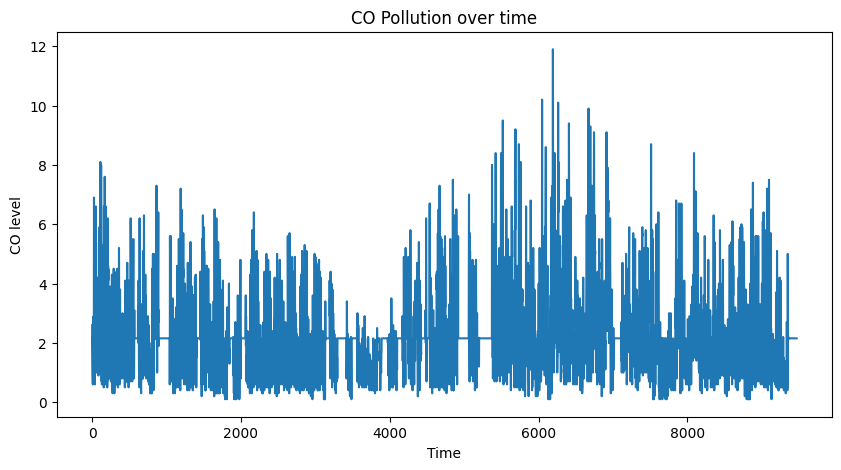

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['CO(GT)'])
plt.title("CO Pollution over time")
plt.xlabel("Time")
plt.ylabel("CO level")
plt.show()

In [ ]:
def categorize_risk_advanced(row):
    if row['CO(GT)'] < 2 and row['NO2(GT)'] < 100:
        return "Low"
    elif row['CO(GT)'] < 5:
        return "Medium"
    else:
        return "High"

data['Risk'] = data.apply(categorize_risk_advanced, axis=1)
data[['CO(GT)', 'NO2(GT)', 'Risk']].head()


,CO(GT),NO2(GT),Risk
0,2.6,113.0,Medium
1,2.0,92.0,Medium
2,2.2,114.0,Medium
3,2.2,122.0,Medium
4,1.6,116.0,Medium


In [ ]:
print(data['Risk'].value_counts())

Risk
Medium    6505
Low       2584
High       382
Name: count, dtype: int64


In [ ]:
data['Risk'] = data['Risk'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [ ]:
X = data.select_dtypes(include=[np.number]).drop('Risk', axis=1)
y = data['Risk']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


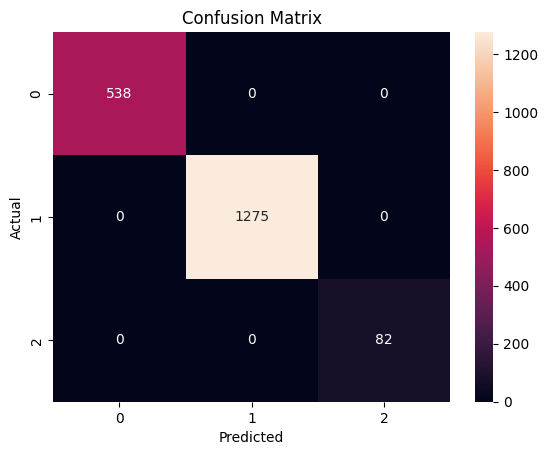

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_df.head())

         Feature  Importance
7        NO2(GT)    0.338924
0         CO(GT)    0.310176
5        NOx(GT)    0.142746
3       C6H6(GT)    0.052379
4  PT08.S2(NMHC)    0.037039


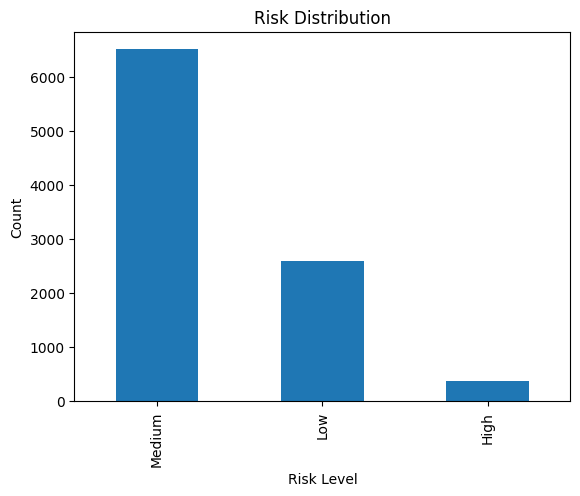

In [ ]:
import matplotlib.pyplot as plt

data['Risk'].value_counts().plot(kind='bar')
plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Conclusion:")
print("The model successfully predicts environmental risk using air quality data.")
print("CO levels are the most important factor influencing risk.")

Conclusion:
The model successfully predicts environmental risk using air quality data.
CO levels are the most important factor influencing risk.
